# U-Net + MobileNetV2 — v1.12.0 (crop 1280 from 2048)

**Notebook version:** `1.12.0` — bump this string on every GitHub push.

Color masks (RGB): red=Window, green=Wall, blue=Roof, white=Other. Same **740 paired 2048×2048** tiles, split **80 / 10 / 10** (seed 42). Train on **1280×1280** window-biased crops with scale/rotation jitter. Val uses 2×2 covering crops of the full 2048 tile (not a center crop). Test is sliding-window on native 2048 with 50% overlap and TTA.

**Drive layout**:

| Path | Content |
|------|----------|
| `My Drive/WWR_Seg_Model/data.zip` | All 740 image+mask pairs at **2048×2048** |
| `/content/data/` | Local cache (fast I/O) |
| `My Drive/WWR_Seg_Model/models/` | Saved models |
| `My Drive/WWR_Seg_Model/results/unet/` | Split list, plots, CSV, paper table |

1. **Runtime → A100 GPU**
2. Run all cells in order (new training; do not load v1.10 / v1.11 weights)
3. If GPU OOM: set `CROP_SIZE = 1024` and `BATCH_SIZE = 4`, then re-run from the dataset cell


In [1]:
VERSION = '1.12.0'
print('U-Net + MobileNetV2  |  VERSION', VERSION)


U-Net + MobileNetV2  |  VERSION 1.12.0


In [2]:
!pip install -q "tensorflow>=2.15" opencv-python-headless scikit-learn tqdm matplotlib pandas tabulate


In [3]:
import os
import shutil
import zipfile
from pathlib import Path

from google.colab import drive

if not Path('/content/drive/MyDrive').exists():
    drive.mount('/content/drive')

DRIVE_BASE = Path('/content/drive/MyDrive/WWR_Seg_Model')
DATA_ZIP = DRIVE_BASE / 'data.zip'
LOCAL_DATA = Path('/content/data')
MODELS_DIR = DRIVE_BASE / 'models'
RESULTS_DIR = DRIVE_BASE / 'results' / 'unet'

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print('Notebook VERSION:', VERSION)
print('Drive base :', DRIVE_BASE)
print('Data zip   :', DATA_ZIP, 'exists=', DATA_ZIP.exists())


Mounted at /content/drive
Notebook VERSION: 1.12.0
Drive base : /content/drive/MyDrive/WWR_Seg_Model
Data zip   : /content/drive/MyDrive/WWR_Seg_Model/data.zip exists= True


In [4]:
IMAGE_EXTS = {'.png', '.jpg', '.jpeg', '.tif', '.tiff'}


def _count_images(folder: Path) -> int:
    if not folder.exists():
        return 0
    return sum(1 for f in folder.iterdir() if f.suffix.lower() in IMAGE_EXTS)


def prepare_local_data(force: bool = False) -> tuple[Path, Path]:
    """Unzip data.zip to /content/data and normalize to train/images + train/masks."""
    train_img = LOCAL_DATA / 'train' / 'images'
    train_msk = LOCAL_DATA / 'train' / 'masks'
    if not force and train_img.exists() and _count_images(train_img) > 0:
        print('Using cached local data:', train_img)
        return train_img, train_msk

    if not DATA_ZIP.exists():
        raise FileNotFoundError(f'Upload data.zip to {DATA_ZIP}')

    tmp = LOCAL_DATA / '_zip_extract'
    if tmp.exists():
        shutil.rmtree(tmp)
    tmp.mkdir(parents=True)

    print('Extracting', DATA_ZIP)
    with zipfile.ZipFile(DATA_ZIP, 'r') as zf:
        zf.extractall(tmp)

    flat_img = tmp / 'images'
    flat_msk = tmp / 'masks'
    if flat_img.exists() and flat_msk.exists():
        train_img.parent.mkdir(parents=True, exist_ok=True)
        shutil.rmtree(LOCAL_DATA / 'train', ignore_errors=True)
        shutil.copytree(flat_img, train_img)
        shutil.copytree(flat_msk, train_msk)
    elif (tmp / 'train' / 'images').exists():
        shutil.rmtree(LOCAL_DATA, ignore_errors=True)
        shutil.copytree(tmp, LOCAL_DATA)
    else:
        raise FileNotFoundError('Expected images/ + masks/ or train/images inside data.zip')

    shutil.rmtree(tmp, ignore_errors=True)
    print('Paired tiles on disk:', _count_images(train_img))
    return train_img, train_msk


images_dir, masks_dir = prepare_local_data(force=False)
print('All 2048 tiles (to be split train/val/test):', images_dir)
print('Masks:', masks_dir)


Extracting /content/drive/MyDrive/WWR_Seg_Model/data.zip
Paired tiles on disk: 740
All 2048 tiles (to be split train/val/test): /content/data/train/images
Masks: /content/data/train/masks


In [5]:
import cv2
import numpy as np
import pandas as pd
import tqdm
import tensorflow as tf
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras import Model, Input
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.layers import (
    BatchNormalization, Concatenate, Conv2D, Conv2DTranspose, Dropout,
    GlobalAveragePooling2D, ReLU, Resizing,
)
from tensorflow.keras.metrics import MeanIoU

tf.keras.mixed_precision.set_global_policy('float32')
tf.config.optimizer.set_jit(False)

OUTPUT_CHANNELS = 4
FULL_SIZE = 2048   # native tile size on disk (images AND masks)
CROP_SIZE = 1280   # model input; larger context than 1024, still fits A100 at batch 2
SIZE_X = CROP_SIZE
SIZE_Y = CROP_SIZE
TEST_STRIDE = CROP_SIZE // 2  # 50% overlap at test
WINDOW_CROP_P = 0.75
SCALE_MIN, SCALE_MAX = 0.88, 1.12
ROTATE_DEG = 8.0
SPLIT_SEED = 42
TEST_FRACTION = 0.10
VAL_FRACTION = 0.10  # of the full 740, not of the remainder
CLASS_NAMES = ('Roof', 'Window', 'Wall', 'Other')
TABLE_NAMES = ('Windows', 'Walls', 'Roofs', 'Other')
TABLE_INDICES = (1, 2, 0, 3)  # Window, Wall, Roof, Other
CLASS_WEIGHTS_NP = np.array([1.0, 4.2, 2.6, 0.45], dtype=np.float32)  # Roof, Window, Wall, Other
FOCAL_ALPHA = (0.12, 0.45, 0.33, 0.10)
DROPOUT_RATE = 0.30
L2_WEIGHT = 1e-4
FINE_TUNE_AT = 80

CLASS_LUT = np.full(256, 3, dtype=np.int32)  # grayscale fallback; unknown → Other
CLASS_LUT[72] = 0
CLASS_LUT[128] = 1
CLASS_LUT[220] = 2
CLASS_LUT[255] = 3
# RGB color masks in data/2048/masks (OpenCV loads BGR; convert first)
RGB_WINDOW = (255, 0, 0)
RGB_WALL = (0, 255, 0)
RGB_ROOF = (0, 0, 255)
RGB_OTHER = (255, 255, 255)


def pair_image_mask_paths(img_dir: Path, mask_dir: Path) -> list[tuple[str, str]]:
    pairs = []
    for img_path in sorted(img_dir.iterdir()):
        if img_path.suffix.lower() not in {'.png', '.jpg', '.jpeg'}:
            continue
        stem = img_path.stem
        mask_stem = stem.replace('_texture', '_mask') if stem.endswith('_texture') else f'{stem}_mask'
        mask_path = None
        for ext in (img_path.suffix, '.png', '.jpg', '.jpeg'):
            candidate = mask_dir / f'{mask_stem}{ext}'
            if candidate.exists():
                mask_path = candidate
                break
            same_name = mask_dir / f'{stem}{ext}'
            if same_name.exists():
                mask_path = same_name
                break
        if mask_path is None:
            raise FileNotFoundError(f'No mask for {img_path.name}')
        pairs.append((str(img_path), str(mask_path)))
    return pairs


def load_rgb(path: str, size: int = FULL_SIZE) -> np.ndarray:
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(path)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    if rgb.shape[0] != size or rgb.shape[1] != size:
        rgb = cv2.resize(rgb, (size, size), interpolation=cv2.INTER_LINEAR)
    return rgb.astype(np.float32) / 255.0


def color_mask_to_class(rgb: np.ndarray) -> np.ndarray:
    """Map RGB mask to {Roof=0, Window=1, Wall=2, Other=3}."""
    out = np.full(rgb.shape[:2], 3, dtype=np.int32)
    out[np.all(rgb == RGB_ROOF, axis=-1)] = 0
    out[np.all(rgb == RGB_WINDOW, axis=-1)] = 1
    out[np.all(rgb == RGB_WALL, axis=-1)] = 2
    out[np.all(rgb == RGB_OTHER, axis=-1)] = 3
    return out


def load_mask(path: str, size: int = FULL_SIZE) -> np.ndarray:
    mask = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if mask is None:
        raise FileNotFoundError(path)
    if mask.ndim == 3:
        rgb = cv2.cvtColor(mask[..., :3], cv2.COLOR_BGR2RGB)
        if rgb.shape[0] != size or rgb.shape[1] != size:
            rgb = cv2.resize(rgb, (size, size), interpolation=cv2.INTER_NEAREST)
        return color_mask_to_class(rgb)
    if mask.shape[0] != size or mask.shape[1] != size:
        mask = cv2.resize(mask, (size, size), interpolation=cv2.INTER_NEAREST)
    return CLASS_LUT[mask].astype(np.int32)


pairs = pair_image_mask_paths(images_dir, masks_dir)
print(f'Paired 2048 tiles: {len(pairs)}')
print('First pair:', pairs[0])
probe = cv2.imread(pairs[0][0])
print('Native image HW:', None if probe is None else probe.shape[:2], '| expected', FULL_SIZE)
if probe is not None and min(probe.shape[:2]) < 1500:
    print('WARNING: files look smaller than 2048. Replace data.zip with native 2048 PNG tiles')
    print('         and re-run prepare_local_data(force=True) after deleting /content/data.')


Paired 2048 tiles: 740
First pair: ('/content/data/train/images/45.4365_-73.4509_texture.png', '/content/data/train/masks/45.4365_-73.4509_mask.png')
Native image HW: (2048, 2048) | expected 2048


In [6]:
trainval_pairs, test_pairs = train_test_split(
    pairs, test_size=TEST_FRACTION, random_state=SPLIT_SEED, shuffle=True
)
val_of_remaining = VAL_FRACTION / (1.0 - TEST_FRACTION)
train_pairs, val_pairs = train_test_split(
    trainval_pairs, test_size=val_of_remaining, random_state=SPLIT_SEED, shuffle=True
)
assert not set(train_pairs) & set(val_pairs)
assert not set(train_pairs) & set(test_pairs)
assert not set(val_pairs) & set(test_pairs)
print(
    f'Split {len(pairs)} native {FULL_SIZE} tiles  '
    f'(seed={SPLIT_SEED}, {int((1 - VAL_FRACTION - TEST_FRACTION) * 100)}/'
    f'{int(VAL_FRACTION * 100)}/{int(TEST_FRACTION * 100)}):'
)
print('  Train:', len(train_pairs), '| Val:', len(val_pairs), '| Test:', len(test_pairs))
print('Files stay on disk at', FULL_SIZE, 'px; the model sees', CROP_SIZE, 'px crops.')
print('Do not load v1.10/v1.11 weights — architecture input size and split protocol changed.')

split_rows = []
for name, file_pairs in (('train', train_pairs), ('val', val_pairs), ('test', test_pairs)):
    for ip, mp in file_pairs:
        split_rows.append({'split': name, 'image': Path(ip).name, 'mask': Path(mp).name})
split_df = pd.DataFrame(split_rows)
split_path = RESULTS_DIR / 'split_740_2048.csv'
split_df.to_csv(split_path, index=False)
print('Saved split list:', split_path)


Split 740 native 2048 tiles  (seed=42, 80/10/10):
  Train: 592 | Val: 74 | Test: 74
Files stay on disk at 2048 px; the model sees 1280 px crops.
Do not load v1.10/v1.11 weights — architecture input size and split protocol changed.
Saved split list: /content/drive/MyDrive/WWR_Seg_Model/results/unet/split_740_2048.csv


In [7]:
LUT_TF = tf.constant(CLASS_LUT, dtype=tf.int32)


def decode_pair(img_path, mask_path):
    img = tf.io.decode_image(tf.io.read_file(img_path), channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, [FULL_SIZE, FULL_SIZE], method='bilinear')

    mask = tf.io.decode_image(tf.io.read_file(mask_path), channels=3, expand_animations=False)
    mask.set_shape([None, None, 3])
    r = tf.cast(mask[..., 0], tf.int32)
    g = tf.cast(mask[..., 1], tf.int32)
    b = tf.cast(mask[..., 2], tf.int32)
    cls = tf.fill(tf.shape(r), 3)
    cls = tf.where((r == 0) & (g == 0) & (b == 255), 0, cls)   # Roof blue
    cls = tf.where((r == 255) & (g == 0) & (b == 0), 1, cls)   # Window red
    cls = tf.where((r == 0) & (g == 255) & (b == 0), 2, cls)   # Wall green
    mask = tf.image.resize(
        tf.expand_dims(tf.cast(cls, tf.float32), -1),
        [FULL_SIZE, FULL_SIZE],
        method='nearest',
    )
    mask = tf.cast(tf.squeeze(mask, -1), tf.int32)
    return img, mask


def random_scale_pair(image, mask):
    scale = tf.random.uniform((), SCALE_MIN, SCALE_MAX)
    new_s = tf.cast(tf.round(scale * tf.cast(FULL_SIZE, tf.float32)), tf.int32)
    new_s = tf.maximum(new_s, CROP_SIZE)
    image = tf.image.resize(image, [new_s, new_s], method='bilinear')
    mask = tf.image.resize(mask[..., tf.newaxis], [new_s, new_s], method='nearest')[..., 0]
    return image, tf.cast(mask, tf.int32)


def _random_origin(h, w, crop):
    y0 = tf.random.uniform((), 0, h - crop + 1, dtype=tf.int32)
    x0 = tf.random.uniform((), 0, w - crop + 1, dtype=tf.int32)
    return y0, x0


def window_biased_crop(image, mask):
    crop = CROP_SIZE
    h = tf.shape(image)[0]
    w = tf.shape(image)[1]

    def _rand():
        return _random_origin(h, w, crop)

    def _win():
        coords = tf.where(tf.equal(mask, 1))
        n = tf.shape(coords)[0]

        def has_win():
            i = tf.random.uniform((), 0, n, dtype=tf.int32)
            cy = tf.cast(coords[i, 0], tf.int32)
            cx = tf.cast(coords[i, 1], tf.int32)
            y0 = tf.clip_by_value(cy - crop // 2, 0, h - crop)
            x0 = tf.clip_by_value(cx - crop // 2, 0, w - crop)
            return y0, x0

        return tf.cond(n > 0, has_win, _rand)

    y0, x0 = tf.cond(tf.random.uniform(()) < WINDOW_CROP_P, _win, _rand)
    image = tf.slice(image, [y0, x0, 0], [crop, crop, 3])
    mask = tf.slice(mask, [y0, x0], [crop, crop])
    image.set_shape([crop, crop, 3])
    mask.set_shape([crop, crop])
    return image, mask


def rotate_pair(image, mask, max_deg=ROTATE_DEG):
    angle = tf.random.uniform((), -max_deg, max_deg) * 0.01745329252
    h = tf.cast(tf.shape(image)[0], tf.float32)
    w = tf.cast(tf.shape(image)[1], tf.float32)
    cos_a = tf.math.cos(angle)
    sin_a = tf.math.sin(angle)
    cx, cy = w * 0.5, h * 0.5
    a0, a1 = cos_a, sin_a
    a2 = (1.0 - cos_a) * cx - sin_a * cy
    b0, b1 = -sin_a, cos_a
    b2 = sin_a * cx + (1.0 - cos_a) * cy
    trans = tf.reshape(tf.stack([a0, a1, a2, b0, b1, b2, 0.0, 0.0]), [1, 8])
    out_hw = tf.shape(image)[:2]
    image = tf.raw_ops.ImageProjectiveTransformV3(
        images=image[None], transforms=trans, output_shape=out_hw,
        interpolation='BILINEAR', fill_mode='REFLECT', fill_value=0.0,
    )[0]
    mask_r = tf.raw_ops.ImageProjectiveTransformV3(
        images=tf.cast(mask[..., None], tf.float32)[None], transforms=trans, output_shape=out_hw,
        interpolation='NEAREST', fill_mode='REFLECT', fill_value=3.0,
    )[0]
    mask = tf.cast(tf.squeeze(mask_r, -1), tf.int32)
    image.set_shape([CROP_SIZE, CROP_SIZE, 3])
    mask.set_shape([CROP_SIZE, CROP_SIZE])
    return image, mask


def augment(image, mask):
    mask = tf.cast(mask, tf.int32)
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(tf.expand_dims(mask, -1))[..., 0]
    image, mask = rotate_pair(image, mask)
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.image.random_contrast(image, 0.85, 1.15)
    image = tf.image.random_saturation(image, 0.85, 1.15)
    noise = tf.random.normal(tf.shape(image), stddev=0.02, dtype=image.dtype)
    image = tf.clip_by_value(image + noise, 0.0, 1.0)
    return image, mask


def covering_crops(image, mask):
    offs = tf.constant([0, FULL_SIZE - CROP_SIZE], dtype=tf.int32)

    def make(i):
        i = tf.cast(i, tf.int32)
        y = offs[i // 2]
        x = offs[tf.math.floormod(i, 2)]
        img_c = tf.slice(image, [y, x, 0], [CROP_SIZE, CROP_SIZE, 3])
        msk_c = tf.slice(mask, [y, x], [CROP_SIZE, CROP_SIZE])
        img_c.set_shape([CROP_SIZE, CROP_SIZE, 3])
        msk_c.set_shape([CROP_SIZE, CROP_SIZE])
        return img_c, msk_c

    return tf.data.Dataset.from_tensor_slices(tf.range(4)).map(make)


def apply_backbone_preprocess(image, mask):
    image = mobilenet_preprocess(image * 255.0)
    return image, mask


def build_dataset(file_pairs, training=True, batch_size=2):
    img_p = [p[0] for p in file_pairs]
    msk_p = [p[1] for p in file_pairs]
    ds = tf.data.Dataset.from_tensor_slices((img_p, msk_p))
    ds = ds.map(decode_pair, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(len(file_pairs))
        ds = ds.map(random_scale_pair, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.map(window_biased_crop, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    else:
        ds = ds.flat_map(covering_crops)
    ds = ds.map(apply_backbone_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


In [8]:
CLASS_WEIGHTS = tf.constant(CLASS_WEIGHTS_NP, dtype=tf.float32)


def conv_block(x, filters, dropout_rate=DROPOUT_RATE, l2=L2_WEIGHT):
    for _ in range(2):
        x = Conv2D(
            filters, 3, padding='same', use_bias=False,
            kernel_regularizer=tf.keras.regularizers.l2(l2),
        )(x)
        x = BatchNormalization()(x)
        x = ReLU()(x)
    return Dropout(dropout_rate)(x)


def upsample_block(filters, size=3):
    return tf.keras.Sequential([
        Conv2DTranspose(filters, size, strides=2, padding='same', use_bias=False),
        BatchNormalization(),
        ReLU(),
    ])


def aspp_block(x, filters=256, rates=(6, 12)):
    branches = []
    b = Conv2D(filters, 1, padding='same', use_bias=False,
               kernel_regularizer=tf.keras.regularizers.l2(L2_WEIGHT))(x)
    b = BatchNormalization()(b)
    branches.append(ReLU()(b))
    for rate in rates:
        b = Conv2D(filters, 3, padding='same', dilation_rate=rate, use_bias=False,
                   kernel_regularizer=tf.keras.regularizers.l2(L2_WEIGHT))(x)
        b = BatchNormalization()(b)
        branches.append(ReLU()(b))
    gap = GlobalAveragePooling2D(keepdims=True)(x)
    gap = Conv2D(filters, 1, padding='same', use_bias=False,
                 kernel_regularizer=tf.keras.regularizers.l2(L2_WEIGHT))(gap)
    gap = BatchNormalization()(gap)
    gap = ReLU()(gap)
    gap = Resizing(int(x.shape[1]), int(x.shape[2]), interpolation='bilinear')(gap)
    branches.append(gap)
    x = Concatenate()(branches)
    x = Conv2D(filters, 1, padding='same', use_bias=False,
               kernel_regularizer=tf.keras.regularizers.l2(L2_WEIGHT))(x)
    x = BatchNormalization()(x)
    return ReLU()(x)


def weighted_dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_oh = tf.one_hot(tf.cast(y_true, tf.int32), OUTPUT_CHANNELS)
    y_pred = tf.cast(y_pred, tf.float32)
    intersection = tf.reduce_sum(y_true_oh * y_pred, axis=[0, 1, 2])
    denom = tf.reduce_sum(y_true_oh, axis=[0, 1, 2]) + tf.reduce_sum(y_pred, axis=[0, 1, 2])
    dice = (2.0 * intersection + smooth) / (denom + smooth)
    return 1.0 - tf.reduce_sum(dice * CLASS_WEIGHTS) / tf.reduce_sum(CLASS_WEIGHTS)


def focal_loss(y_true, y_pred, gamma=2.0):
    y_true_oh = tf.one_hot(tf.cast(y_true, tf.int32), OUTPUT_CHANNELS)
    y_pred = tf.clip_by_value(tf.cast(y_pred, tf.float32), 1e-7, 1.0 - 1e-7)
    ce = -y_true_oh * tf.math.log(y_pred)
    alpha = tf.reshape(tf.constant(FOCAL_ALPHA, dtype=tf.float32), (1, 1, 1, -1))
    weight = alpha * y_true_oh * tf.pow(1.0 - y_pred, gamma)
    return tf.reduce_mean(tf.reduce_sum(weight * ce, axis=-1))


def boundary_loss(y_true, y_pred):
    y_true_oh = tf.cast(tf.one_hot(tf.cast(y_true, tf.int32), OUTPUT_CHANNELS), tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    sobel = tf.image.sobel_edges(y_true_oh)
    edges = tf.sqrt(tf.reduce_sum(tf.square(sobel), axis=-1) + 1e-6)
    edges = tf.clip_by_value(edges, 0.0, 1.0)
    ce = -y_true_oh * tf.math.log(tf.clip_by_value(y_pred, 1e-7, 1.0))
    return tf.reduce_mean(tf.reduce_sum(ce * (1.0 + 3.0 * edges), axis=-1))


def window_wall_confusion_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    y_pred = tf.cast(y_pred, tf.float32)
    true_win = tf.cast(tf.equal(y_true, 1), tf.float32)
    true_wall = tf.cast(tf.equal(y_true, 2), tf.float32)
    return tf.reduce_mean(true_win * y_pred[..., 2] + true_wall * y_pred[..., 1])


def combined_loss(y_true, y_pred):
    return (
        0.45 * weighted_dice_loss(y_true, y_pred)
        + 0.30 * focal_loss(y_true, y_pred)
        + 0.15 * boundary_loss(y_true, y_pred)
        + 0.10 * window_wall_confusion_loss(y_true, y_pred)
    )


class MeanIoUFromLogits(MeanIoU):
    """MeanIoU for softmax output — argmax predictions before update."""

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.cast(tf.argmax(y_pred, axis=-1), tf.int32)
        return super().update_state(y_true, y_pred, sample_weight)


class ClassIoU(tf.keras.metrics.Metric):
    def __init__(self, class_id, name, **kwargs):
        super().__init__(name=name, **kwargs)
        self.class_id = int(class_id)
        self.tp = self.add_weight(name='tp', initializer='zeros')
        self.fp = self.add_weight(name='fp', initializer='zeros')
        self.fn = self.add_weight(name='fn', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.cast(tf.argmax(y_pred, axis=-1), tf.int32)
        true_c = tf.equal(y_true, self.class_id)
        pred_c = tf.equal(y_pred, self.class_id)
        self.tp.assign_add(tf.reduce_sum(tf.cast(tf.logical_and(true_c, pred_c), tf.float32)))
        self.fp.assign_add(tf.reduce_sum(tf.cast(tf.logical_and(tf.logical_not(true_c), pred_c), tf.float32)))
        self.fn.assign_add(tf.reduce_sum(tf.cast(tf.logical_and(true_c, tf.logical_not(pred_c)), tf.float32)))

    def result(self):
        return self.tp / (self.tp + self.fp + self.fn + 1e-6)

    def reset_state(self):
        self.tp.assign(0.0)
        self.fp.assign(0.0)
        self.fn.assign(0.0)


def unet_model(output_channels=4, dropout_rate=DROPOUT_RATE):
    h, w, c = SIZE_Y, SIZE_X, 3
    base = MobileNetV2(input_shape=[h, w, c], include_top=False, weights='imagenet')
    layer_names = [
        'block_1_expand_relu', 'block_3_expand_relu', 'block_6_expand_relu',
        'block_13_expand_relu', 'block_16_project',
    ]
    down_stack = Model(base.input, [base.get_layer(n).output for n in layer_names], name='mobilenetv2_encoder')
    down_stack.trainable = False

    decoder_filters = (256, 128, 64, 32)
    up_stack = [upsample_block(f) for f in decoder_filters]

    inputs = Input(shape=[h, w, c], name='input_image')
    skips = down_stack(inputs)
    x = aspp_block(skips[-1], filters=256)
    for up, skip, filt in zip(up_stack, reversed(skips[:-1]), decoder_filters):
        skip = Conv2D(filt, 1, padding='same', use_bias=False)(skip)
        skip = BatchNormalization()(skip)
        skip = ReLU()(skip)
        x = up(x)
        x = Concatenate()([x, skip])
        x = conv_block(x, filt, dropout_rate)
    x = Conv2DTranspose(output_channels, 3, strides=2, padding='same', dtype='float32')(x)
    outputs = tf.keras.layers.Activation('softmax', dtype='float32', name='mask')(x)
    return Model(inputs, outputs, name='unet_mobilenetv2'), down_stack


In [9]:
def create_mask(pred_mask):
    return tf.argmax(pred_mask, axis=-1)[0].numpy()


def show_predictions(epoch, tag='train'):
    for xb, yb in val_ds.take(1):
        pred = np.argmax(model.predict(xb[:1], verbose=0), axis=-1)[0]
        vis = np.clip((xb[0].numpy() + 1.0) * 0.5, 0.0, 1.0)
        gt = yb[0].numpy()
        fig = plt.figure(figsize=(12, 4))
        for col, (title, arr) in enumerate([
            ('Input (' + str(CROP_SIZE) + ' crop)', vis),
            ('Ground Truth', gt),
            ('Prediction', pred),
        ]):
            ax = fig.add_subplot(1, 3, col + 1)
            ax.imshow(arr if col == 0 else arr, cmap=None if col == 0 else 'jet', vmin=0, vmax=3 if col else None)
            ax.set_title(title)
            ax.axis('off')
        fig.suptitle(f'{tag} · epoch {epoch + 1}')
        fig.savefig(RESULTS_DIR / f'{tag}_epoch_{epoch + 1:03d}.png', dpi=100, bbox_inches='tight')
        plt.show()
        plt.close(fig)
        break


class DisplayCallback(tf.keras.callbacks.Callback):
    def __init__(self, every_n=5, tag='stage'):
        super().__init__()
        self.every_n = every_n
        self.tag = tag

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0 or epoch == 0:
            show_predictions(epoch, tag=self.tag)


In [10]:
def train_metrics():
    return [
        tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
        MeanIoUFromLogits(num_classes=OUTPUT_CHANNELS, name='mean_iou'),
        ClassIoU(1, name='iou_window'),
        ClassIoU(2, name='iou_wall'),
    ]


def make_optimizer(lr):
    kwargs = dict(learning_rate=lr, weight_decay=1e-5, clipnorm=1.0)
    try:
        return tf.keras.optimizers.AdamW(**kwargs, use_ema=True, ema_momentum=0.999)
    except TypeError:
        return tf.keras.optimizers.AdamW(**kwargs)


def compile_model(lr):
    model.compile(
        optimizer=make_optimizer(lr),
        loss=combined_loss,
        metrics=train_metrics(),
        jit_compile=False,
    )


model, down_stack = unet_model(OUTPUT_CHANNELS, dropout_rate=DROPOUT_RATE)
compile_model(1e-3)
model.summary()


/tmp/ipykernel_12830/1515906782.py:130: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(input_shape=[h, w, c], include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "unet_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 1280,      │          0 │ -                 │
│ (InputLayer)        │ 1280, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_encoder │ [(None, 640, 640, │  1,841,984 │ input_image[0][0] │
│ (Functional)        │ 96), (None, 320,  │            │                   │
│                     │ 320, 144), (None, │            │                   │
│                     │ 160, 160, 192),   │            │                   │
│                     │ (None, 80, 80,    │            │                   │
│                     │ 576), (None, 40,  │            │                   │
│                     │ 40, 320)]         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1, 1, 320) │          0 │ mobilenetv2_enco… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 1, 1, 256) │     81,920 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 40, 40,    │     81,920 │ mobilenetv2_enco… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 40, 40,    │    737,280 │ mobilenetv2_enco… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 40, 40,    │    737,280 │ mobilenetv2_enco… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1, 1, 256) │      1,024 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │      1,024 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │      1,024 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │      1,024 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_7 (ReLU)      │ (None, 1, 1, 256) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 40, 40,    │          0 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_5 (ReLU)      │ (None, 40, 40,    │          0 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_6 (ReLU)      │ (None, 40, 40,    │          0 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing (Resizing) │ (None, 40, 40,    │          0 │ re_lu_7[0][0]   

 Total params: 7,267,780 (27.72 MB)

 Trainable params: 5,419,396 (20.67 MB)

 Non-trainable params: 1,848,384 (7.05 MB)

Stage 1: frozen MobileNetV2 encoder, train decoder
Epoch 1/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.5526 - iou_wall: 0.1986 - iou_window: 0.1287 - loss: 0.6698 - mean_iou: 0.2808

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


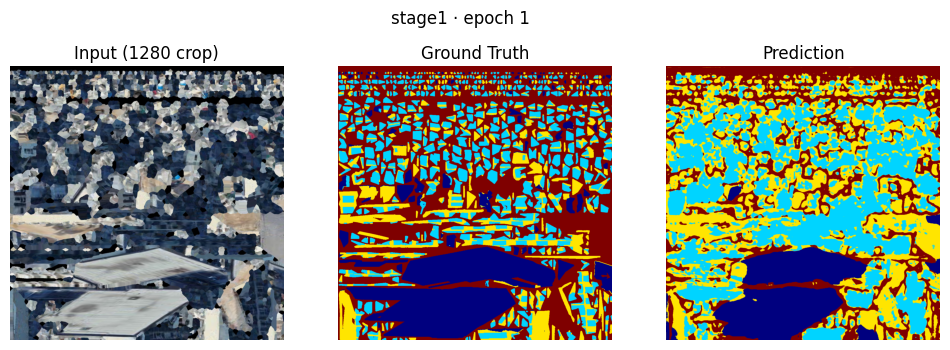


Epoch 1: val_iou_window improved from None to 0.13560, saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_mobilenetv2_v1.12.0.keras

Epoch 1: finished saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_mobilenetv2_v1.12.0.keras
296/296 ━━━━━━━━━━━━━━━━━━━━ 174s 381ms/step - accuracy: 0.6084 - iou_wall: 0.2313 - iou_window: 0.1839 - loss: 0.5892 - mean_iou: 0.3357 - val_accuracy: 0.4569 - val_iou_wall: 0.1841 - val_iou_window: 0.1356 - val_loss: 0.7338 - val_mean_iou: 0.2667 - learning_rate: 0.0010
Epoch 2/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.6542 - iou_wall: 0.2818 - iou_window: 0.2501 - loss: 0.5245 - mean_iou: 0.3943
Epoch 2: val_iou_window improved from 0.13560 to 0.26905, saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_mobilenetv2_v1.12.0.keras

Epoch 2: finished saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_mobilenetv2_v1.12.0.keras
296/296 ━━━━━━━━━━━━━━━━━━━━ 119s 319ms/step - accuracy: 0.663

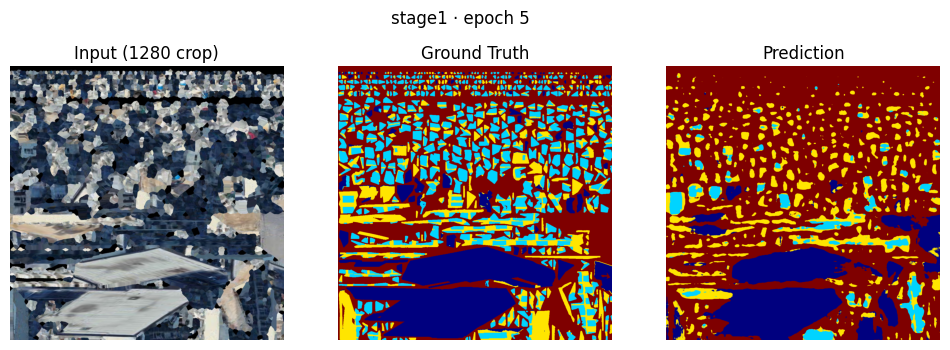


Epoch 5: val_iou_window did not improve from 0.26905
296/296 ━━━━━━━━━━━━━━━━━━━━ 120s 325ms/step - accuracy: 0.6854 - iou_wall: 0.3148 - iou_window: 0.2802 - loss: 0.4928 - mean_iou: 0.4223 - val_accuracy: 0.6968 - val_iou_wall: 0.2875 - val_iou_window: 0.2646 - val_loss: 0.4977 - val_mean_iou: 0.4146 - learning_rate: 0.0010
Epoch 6/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.6823 - iou_wall: 0.3170 - iou_window: 0.2948 - loss: 0.4858 - mean_iou: 0.4260
Epoch 6: val_iou_window improved from 0.26905 to 0.29447, saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_mobilenetv2_v1.12.0.keras

Epoch 6: finished saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_mobilenetv2_v1.12.0.keras
296/296 ━━━━━━━━━━━━━━━━━━━━ 118s 319ms/step - accuracy: 0.6905 - iou_wall: 0.3215 - iou_window: 0.2913 - loss: 0.4845 - mean_iou: 0.4302 - val_accuracy: 0.6723 - val_iou_wall: 0.3357 - val_iou_window: 0.2945 - val_loss: 0.4964 - val_mean_iou: 0.4190 - learning_rat

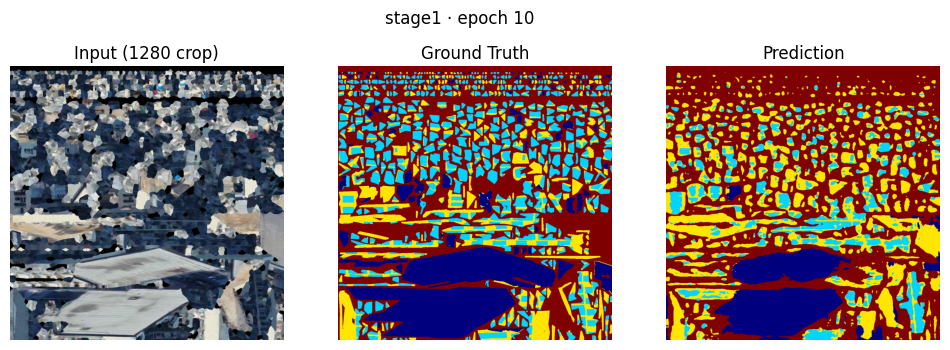


Epoch 10: val_iou_window did not improve from 0.29447
296/296 ━━━━━━━━━━━━━━━━━━━━ 120s 328ms/step - accuracy: 0.7026 - iou_wall: 0.3346 - iou_window: 0.3056 - loss: 0.4745 - mean_iou: 0.4422 - val_accuracy: 0.6682 - val_iou_wall: 0.3128 - val_iou_window: 0.2539 - val_loss: 0.5090 - val_mean_iou: 0.3940 - learning_rate: 0.0010
Epoch 11/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.7094 - iou_wall: 0.3420 - iou_window: 0.3083 - loss: 0.4706 - mean_iou: 0.4540
Epoch 11: val_iou_window did not improve from 0.29447

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
296/296 ━━━━━━━━━━━━━━━━━━━━ 117s 316ms/step - accuracy: 0.7061 - iou_wall: 0.3366 - iou_window: 0.3084 - loss: 0.4720 - mean_iou: 0.4475 - val_accuracy: 0.6750 - val_iou_wall: 0.2793 - val_iou_window: 0.2530 - val_loss: 0.5337 - val_mean_iou: 0.3939 - learning_rate: 0.0010
Epoch 12/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.7168 - iou_wall: 0.3567 - iou_window: 0.2981 -

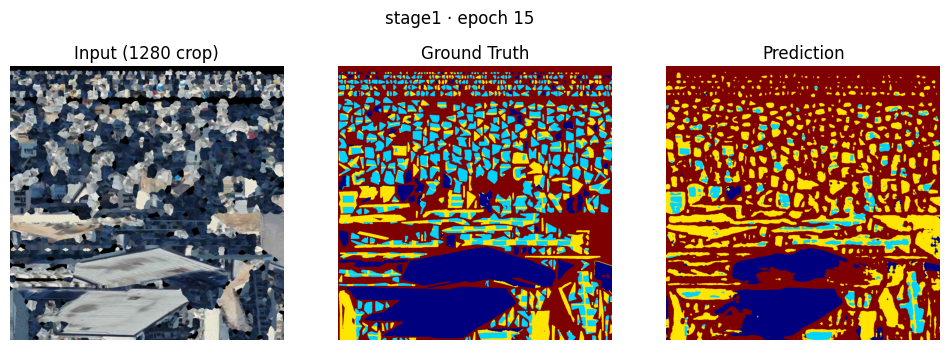


Epoch 15: val_iou_window improved from 0.30504 to 0.30976, saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_mobilenetv2_v1.12.0.keras

Epoch 15: finished saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_mobilenetv2_v1.12.0.keras
296/296 ━━━━━━━━━━━━━━━━━━━━ 121s 328ms/step - accuracy: 0.7258 - iou_wall: 0.3617 - iou_window: 0.3250 - loss: 0.4487 - mean_iou: 0.4710 - val_accuracy: 0.7042 - val_iou_wall: 0.3500 - val_iou_window: 0.3098 - val_loss: 0.4632 - val_mean_iou: 0.4355 - learning_rate: 5.0000e-04
Epoch 16/20
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.7271 - iou_wall: 0.3589 - iou_window: 0.3189 - loss: 0.4496 - mean_iou: 0.4697
Epoch 16: val_iou_window did not improve from 0.30976
296/296 ━━━━━━━━━━━━━━━━━━━━ 118s 317ms/step - accuracy: 0.7291 - iou_wall: 0.3624 - iou_window: 0.3275 - loss: 0.4473 - mean_iou: 0.4741 - val_accuracy: 0.6466 - val_iou_wall: 0.3235 - val_iou_window: 0.2966 - val_loss: 0.4919 - val_mean_iou: 0.4048 - lear

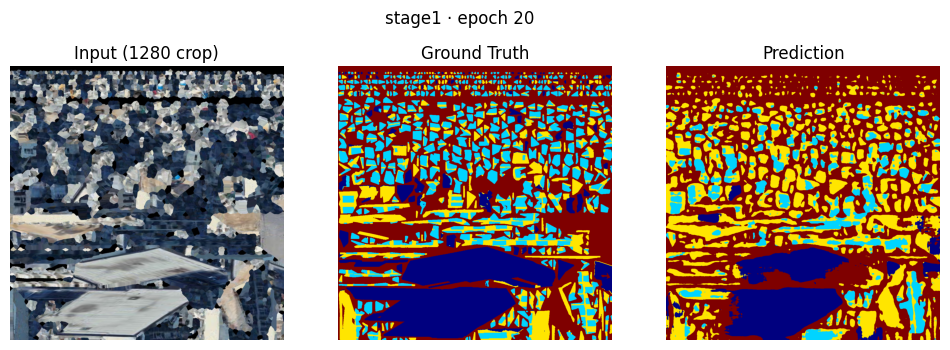


Epoch 20: val_iou_window did not improve from 0.32594
296/296 ━━━━━━━━━━━━━━━━━━━━ 120s 325ms/step - accuracy: 0.7329 - iou_wall: 0.3756 - iou_window: 0.3383 - loss: 0.4388 - mean_iou: 0.4829 - val_accuracy: 0.6848 - val_iou_wall: 0.3416 - val_iou_window: 0.2711 - val_loss: 0.4768 - val_mean_iou: 0.4303 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 19.


In [11]:
BATCH_SIZE = 2  # 1280 crops on A100 40GB; if OOM: CROP_SIZE=1024 and BATCH_SIZE=4
STAGE1_EPOCHS = 20
STAGE2_EPOCHS = 80
CHECKPOINT_MONITOR = 'val_iou_window'
checkpoint_path = MODELS_DIR / f'unet_mobilenetv2_v{VERSION}.keras'

train_ds = build_dataset(train_pairs, training=True, batch_size=BATCH_SIZE)
val_ds = build_dataset(val_pairs, training=False, batch_size=BATCH_SIZE)
steps_per_epoch = int(np.ceil(len(train_pairs) / BATCH_SIZE))

def make_callbacks(tag, patience):
    cbs = [
        DisplayCallback(every_n=5, tag=tag),
        tf.keras.callbacks.ModelCheckpoint(
            str(checkpoint_path), monitor=CHECKPOINT_MONITOR, mode='max',
            save_best_only=True, verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor=CHECKPOINT_MONITOR, mode='max', patience=patience,
            restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor=CHECKPOINT_MONITOR, mode='max', factor=0.5, patience=5,
            min_lr=1e-7, verbose=1,
        ),
    ]
    return cbs

print('Stage 1: frozen MobileNetV2 encoder, train decoder')
history1 = model.fit(
    train_ds, validation_data=val_ds, epochs=STAGE1_EPOCHS,
    callbacks=make_callbacks('stage1', patience=8),
)


Stage 2: fine-tune encoder from layer 80 (BatchNorm stays frozen)
Loaded best Stage-1 weights
Epoch 1/80
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.7373 - iou_wall: 0.3812 - iou_window: 0.3485 - loss: 0.4338 - mean_iou: 0.4889

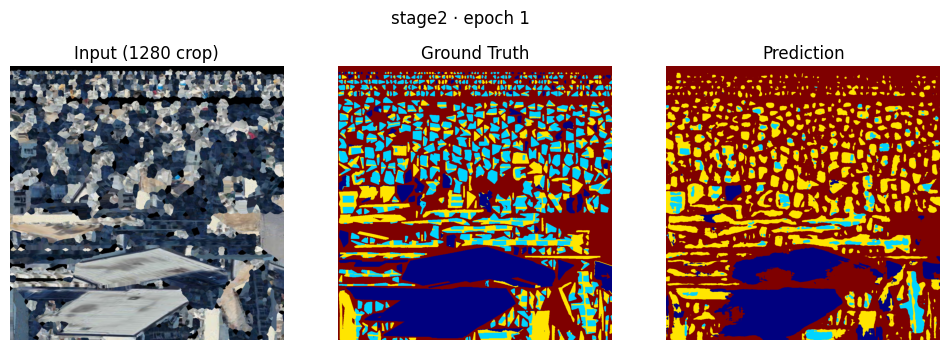


Epoch 1: val_iou_window improved from None to 0.33420, saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_mobilenetv2_v1.12.0.keras

Epoch 1: finished saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_mobilenetv2_v1.12.0.keras
296/296 ━━━━━━━━━━━━━━━━━━━━ 152s 343ms/step - accuracy: 0.7401 - iou_wall: 0.3858 - iou_window: 0.3504 - loss: 0.4303 - mean_iou: 0.4929 - val_accuracy: 0.7455 - val_iou_wall: 0.3808 - val_iou_window: 0.3342 - val_loss: 0.4327 - val_mean_iou: 0.4777
Epoch 2/80
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.7438 - iou_wall: 0.3909 - iou_window: 0.3658 - loss: 0.4241 - mean_iou: 0.5023
Epoch 2: val_iou_window did not improve from 0.33420
296/296 ━━━━━━━━━━━━━━━━━━━━ 118s 317ms/step - accuracy: 0.7477 - iou_wall: 0.3895 - iou_window: 0.3565 - loss: 0.4232 - mean_iou: 0.5033 - val_accuracy: 0.7227 - val_iou_wall: 0.3832 - val_iou_window: 0.3305 - val_loss: 0.4389 - val_mean_iou: 0.4711
Epoch 3/80
296/296 ━━━━━━━━━━━━━━━━━━━━ 0

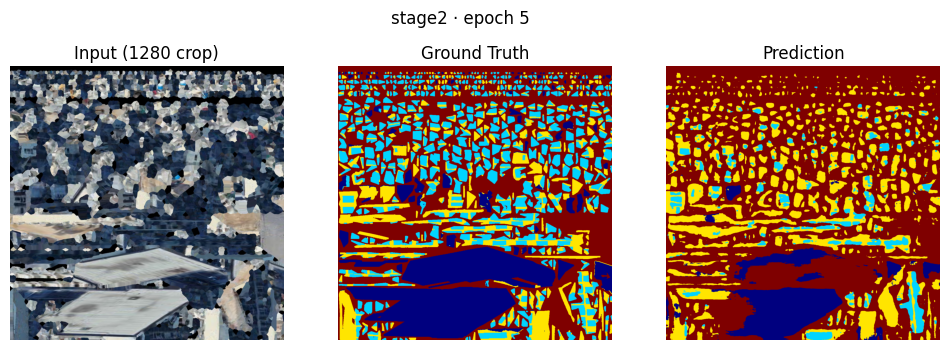


Epoch 5: val_iou_window improved from 0.33420 to 0.33894, saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_mobilenetv2_v1.12.0.keras

Epoch 5: finished saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_mobilenetv2_v1.12.0.keras
296/296 ━━━━━━━━━━━━━━━━━━━━ 121s 330ms/step - accuracy: 0.7590 - iou_wall: 0.4089 - iou_window: 0.3696 - loss: 0.4105 - mean_iou: 0.5194 - val_accuracy: 0.7443 - val_iou_wall: 0.3953 - val_iou_window: 0.3389 - val_loss: 0.4280 - val_mean_iou: 0.4698
Epoch 6/80
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.7635 - iou_wall: 0.4151 - iou_window: 0.3782 - loss: 0.4063 - mean_iou: 0.5255
Epoch 6: val_iou_window improved from 0.33894 to 0.33984, saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_mobilenetv2_v1.12.0.keras

Epoch 6: finished saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_mobilenetv2_v1.12.0.keras
296/296 ━━━━━━━━━━━━━━━━━━━━ 119s 322ms/step - accuracy: 0.7601 - iou_wall: 0.4110 

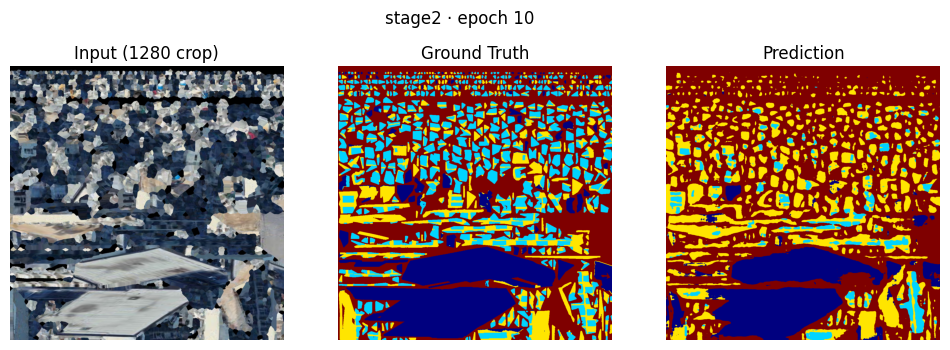


Epoch 10: val_iou_window did not improve from 0.33984
296/296 ━━━━━━━━━━━━━━━━━━━━ 120s 326ms/step - accuracy: 0.7721 - iou_wall: 0.4200 - iou_window: 0.3771 - loss: 0.3987 - mean_iou: 0.5340 - val_accuracy: 0.7378 - val_iou_wall: 0.3893 - val_iou_window: 0.3327 - val_loss: 0.4276 - val_mean_iou: 0.4817
Epoch 11/80
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.7753 - iou_wall: 0.4290 - iou_window: 0.3797 - loss: 0.3959 - mean_iou: 0.5376
Epoch 11: val_iou_window did not improve from 0.33984
296/296 ━━━━━━━━━━━━━━━━━━━━ 118s 318ms/step - accuracy: 0.7729 - iou_wall: 0.4227 - iou_window: 0.3793 - loss: 0.3973 - mean_iou: 0.5346 - val_accuracy: 0.7433 - val_iou_wall: 0.3774 - val_iou_window: 0.3301 - val_loss: 0.4408 - val_mean_iou: 0.4571
Epoch 12/80
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.7730 - iou_wall: 0.4289 - iou_window: 0.3755 - loss: 0.3992 - mean_iou: 0.5339
Epoch 12: val_iou_window did not improve from 0.33984
296/296 ━━━━━━━━━━━━━━━━━━━━ 117s 316ms

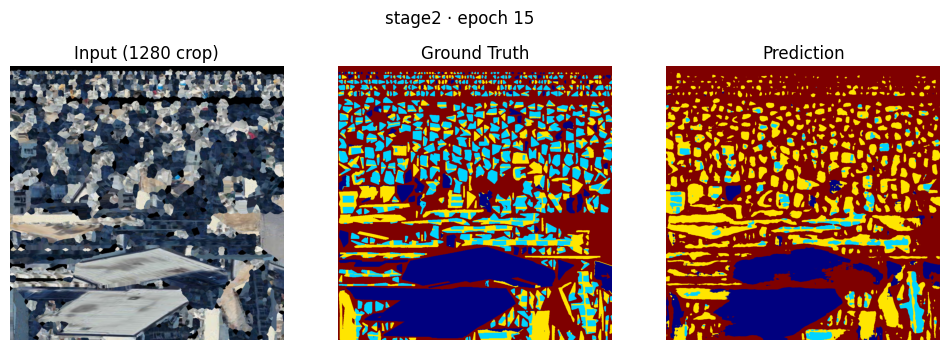


Epoch 15: val_iou_window improved from 0.33984 to 0.34294, saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_mobilenetv2_v1.12.0.keras

Epoch 15: finished saving model to /content/drive/MyDrive/WWR_Seg_Model/models/unet_mobilenetv2_v1.12.0.keras
296/296 ━━━━━━━━━━━━━━━━━━━━ 122s 332ms/step - accuracy: 0.7790 - iou_wall: 0.4295 - iou_window: 0.3819 - loss: 0.3936 - mean_iou: 0.5423 - val_accuracy: 0.7600 - val_iou_wall: 0.4026 - val_iou_window: 0.3429 - val_loss: 0.4201 - val_mean_iou: 0.4883
Epoch 16/80
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.7807 - iou_wall: 0.4302 - iou_window: 0.3774 - loss: 0.3952 - mean_iou: 0.5435
Epoch 16: val_iou_window did not improve from 0.34294
296/296 ━━━━━━━━━━━━━━━━━━━━ 119s 317ms/step - accuracy: 0.7833 - iou_wall: 0.4354 - iou_window: 0.3879 - loss: 0.3875 - mean_iou: 0.5495 - val_accuracy: 0.7732 - val_iou_wall: 0.4137 - val_iou_window: 0.3379 - val_loss: 0.4103 - val_mean_iou: 0.5096
Epoch 17/80
296/296 ━━━━━━━━━━━━━━

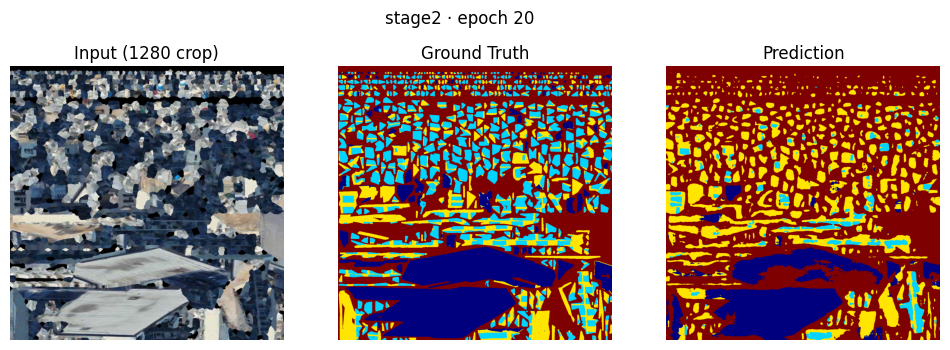


Epoch 20: val_iou_window did not improve from 0.34294
296/296 ━━━━━━━━━━━━━━━━━━━━ 121s 327ms/step - accuracy: 0.7905 - iou_wall: 0.4481 - iou_window: 0.3938 - loss: 0.3807 - mean_iou: 0.5600 - val_accuracy: 0.7667 - val_iou_wall: 0.4067 - val_iou_window: 0.3374 - val_loss: 0.4209 - val_mean_iou: 0.4909
Epoch 21/80
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.7898 - iou_wall: 0.4462 - iou_window: 0.4056 - loss: 0.3803 - mean_iou: 0.5628
Epoch 21: val_iou_window did not improve from 0.34294
296/296 ━━━━━━━━━━━━━━━━━━━━ 118s 319ms/step - accuracy: 0.7898 - iou_wall: 0.4451 - iou_window: 0.3929 - loss: 0.3817 - mean_iou: 0.5575 - val_accuracy: 0.7580 - val_iou_wall: 0.3987 - val_iou_window: 0.3383 - val_loss: 0.4179 - val_mean_iou: 0.4908
Epoch 22/80
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.7912 - iou_wall: 0.4435 - iou_window: 0.3763 - loss: 0.3875 - mean_iou: 0.5563
Epoch 22: val_iou_window did not improve from 0.34294
296/296 ━━━━━━━━━━━━━━━━━━━━ 118s 319ms

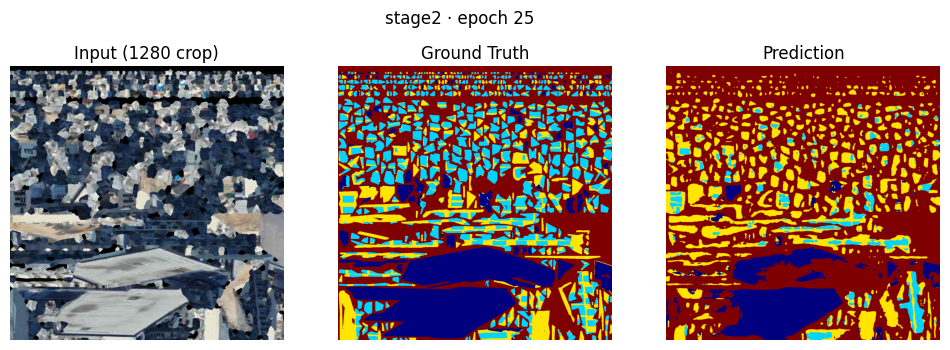


Epoch 25: val_iou_window did not improve from 0.34294
296/296 ━━━━━━━━━━━━━━━━━━━━ 121s 327ms/step - accuracy: 0.7969 - iou_wall: 0.4548 - iou_window: 0.3963 - loss: 0.3756 - mean_iou: 0.5688 - val_accuracy: 0.7636 - val_iou_wall: 0.3968 - val_iou_window: 0.3401 - val_loss: 0.4265 - val_mean_iou: 0.4822
Epoch 26/80
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.8012 - iou_wall: 0.4714 - iou_window: 0.4184 - loss: 0.3626 - mean_iou: 0.5802
Epoch 26: val_iou_window did not improve from 0.34294
296/296 ━━━━━━━━━━━━━━━━━━━━ 118s 319ms/step - accuracy: 0.7981 - iou_wall: 0.4603 - iou_window: 0.4022 - loss: 0.3715 - mean_iou: 0.5713 - val_accuracy: 0.7677 - val_iou_wall: 0.4130 - val_iou_window: 0.3370 - val_loss: 0.4189 - val_mean_iou: 0.4959
Epoch 27/80
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.8037 - iou_wall: 0.4562 - iou_window: 0.4018 - loss: 0.3685 - mean_iou: 0.5740
Epoch 27: val_iou_window did not improve from 0.34294
296/296 ━━━━━━━━━━━━━━━━━━━━ 118s 318ms

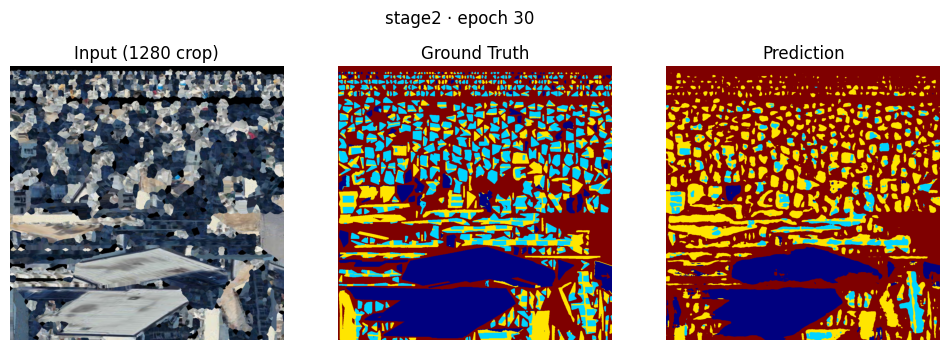


Epoch 30: val_iou_window did not improve from 0.34294
296/296 ━━━━━━━━━━━━━━━━━━━━ 120s 327ms/step - accuracy: 0.8044 - iou_wall: 0.4635 - iou_window: 0.4113 - loss: 0.3665 - mean_iou: 0.5790 - val_accuracy: 0.7703 - val_iou_wall: 0.4078 - val_iou_window: 0.3384 - val_loss: 0.4166 - val_mean_iou: 0.4962
Epoch 30: early stopping
Restoring model weights from the end of the best epoch: 15.
Best model → /content/drive/MyDrive/WWR_Seg_Model/models/unet_mobilenetv2_v1.12.0.keras


In [12]:
print('Stage 2: fine-tune encoder from layer', FINE_TUNE_AT, '(BatchNorm stays frozen)')
if checkpoint_path.exists():
    model.load_weights(str(checkpoint_path))
    print('Loaded best Stage-1 weights')
down_stack.trainable = True
for i, layer in enumerate(down_stack.layers):
    if isinstance(layer, BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = i >= FINE_TUNE_AT

cosine = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=3e-5,
    decay_steps=max(steps_per_epoch * STAGE2_EPOCHS, 1),
    alpha=0.01,
)
model.compile(
    optimizer=make_optimizer(cosine),
    loss=combined_loss,
    metrics=train_metrics(),
    jit_compile=False,
)

history2 = model.fit(
    train_ds, validation_data=val_ds, epochs=STAGE2_EPOCHS,
    callbacks=[
        DisplayCallback(every_n=5, tag='stage2'),
        tf.keras.callbacks.ModelCheckpoint(
            str(checkpoint_path), monitor=CHECKPOINT_MONITOR, mode='max',
            save_best_only=True, verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor=CHECKPOINT_MONITOR, mode='max', patience=15,
            restore_best_weights=True, verbose=1,
        ),
    ],
)
print('Best model →', checkpoint_path)


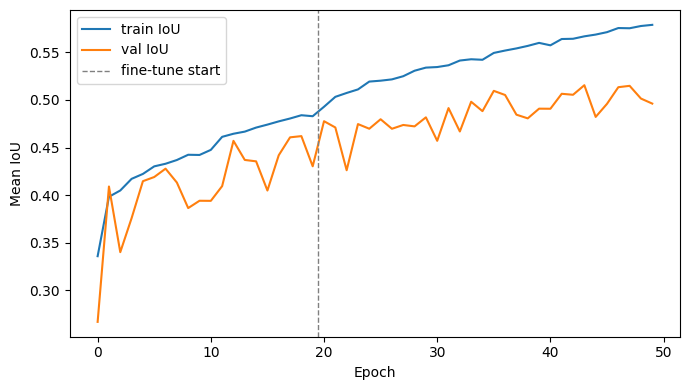

In [13]:
def merge_history(*histories):
    merged = {}
    for h in histories:
        for k, v in h.history.items():
            merged.setdefault(k, []).extend(v)
    return merged


hist = merge_history(history1, history2)
iou_key = 'mean_iou' if 'mean_iou' in hist else 'mean_io_u'
plt.figure(figsize=(7, 4))
plt.plot(hist[iou_key], label='train IoU')
plt.plot(hist['val_' + iou_key], label='val IoU')
plt.axvline(len(history1.history[iou_key]) - 0.5, color='gray', ls='--', lw=1, label='fine-tune start')
plt.xlabel('Epoch')
plt.ylabel('Mean IoU')
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curve.png', dpi=120, bbox_inches='tight')
plt.show()


## Test-set class-wise metrics

Pixel-wise Precision, Recall, F1-score, and IoU with **sliding-window** inference on the held-out **2048×2048 test tiles** (10% of the 740 pairs, never used in training).


In [14]:
def predict_sliding(image: np.ndarray, crop=CROP_SIZE, stride=None, tta=True) -> np.ndarray:
    if stride is None:
        stride = TEST_STRIDE
    h, w, _ = image.shape
    acc = np.zeros((h, w, OUTPUT_CHANNELS), np.float32)
    cnt = np.zeros((h, w, 1), np.float32)
    ys = list(range(0, max(h - crop, 0) + 1, stride))
    xs = list(range(0, max(w - crop, 0) + 1, stride))
    if ys[-1] != h - crop:
        ys.append(h - crop)
    if xs[-1] != w - crop:
        xs.append(w - crop)
    for y in ys:
        for x in xs:
            patch = image[y:y + crop, x:x + crop]
            probs = model.predict(mobilenet_preprocess(patch[np.newaxis, ...] * 255.0), verbose=0)[0]
            if tta:
                flipped = patch[:, ::-1]
                probs_f = model.predict(mobilenet_preprocess(flipped[np.newaxis, ...] * 255.0), verbose=0)[0][:, ::-1]
                probs = 0.5 * (probs + probs_f)
            acc[y:y + crop, x:x + crop] += probs
            cnt[y:y + crop, x:x + crop] += 1.0
    return np.argmax(acc / np.maximum(cnt, 1e-6), axis=-1).astype(np.int32)


def load_eval_pairs(file_pairs):
    xs, ys = [], []
    for ip, mp in tqdm.tqdm(file_pairs, desc='Loading full-res tiles'):
        xs.append(load_rgb(ip, FULL_SIZE))
        ys.append(load_mask(mp, FULL_SIZE))
    return xs, ys


def confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, num_classes=4) -> np.ndarray:
    t = y_true.ravel().astype(np.int32)
    p = y_pred.ravel().astype(np.int32)
    valid = (t >= 0) & (t < num_classes) & (p >= 0) & (p < num_classes)
    return np.bincount(t[valid] * num_classes + p[valid], minlength=num_classes * num_classes).reshape(num_classes, num_classes)


def classwise_table(cm: np.ndarray) -> pd.DataFrame:
    rows = []
    for display_name, idx in zip(TABLE_NAMES, TABLE_INDICES):
        tp = cm[idx, idx]
        fp = cm[:, idx].sum() - tp
        fn = cm[idx, :].sum() - tp
        precision = tp / (tp + fp + 1e-6)
        recall = tp / (tp + fn + 1e-6)
        f1 = 2 * precision * recall / (precision + recall + 1e-6)
        iou = tp / (tp + fp + fn + 1e-6)
        rows.append({
            'Class': display_name,
            'Precision': float(precision),
            'Recall': float(recall),
            'F1-score': float(f1),
            'IoU': float(iou),
        })
    df = pd.DataFrame(rows)
    mean = df[['Precision', 'Recall', 'F1-score', 'IoU']].mean()
    df.loc[len(df)] = ['Mean', mean['Precision'], mean['Recall'], mean['F1-score'], mean['IoU']]
    return df


eval_split = 'test'
eval_pairs = test_pairs
print(f'Held-out 2048 test tiles: {len(eval_pairs)} (from the same 740 as train/val; no 512 test set)')

X_eval, y_eval = load_eval_pairs(eval_pairs)
print('Sliding-window inference on', FULL_SIZE, 'tiles with', CROP_SIZE, 'crops, stride', TEST_STRIDE, '+ TTA')
y_hat = [predict_sliding(img, tta=True) for img in tqdm.tqdm(X_eval, desc='Predict')]
y_eval = np.stack(y_eval, axis=0)
y_hat = np.stack(y_hat, axis=0)
cm = confusion_matrix(y_eval, y_hat)
metrics_df = classwise_table(cm)
metrics_df_fmt = metrics_df.copy()
for col in ('Precision', 'Recall', 'F1-score', 'IoU'):
    metrics_df_fmt[col] = metrics_df_fmt[col].map(lambda v: f'{v:.4f}')

def dataframe_to_markdown(df: pd.DataFrame) -> str:
    cols = list(df.columns)
    lines = ['| ' + ' | '.join(cols) + ' |', '| ' + ' | '.join(['---'] * len(cols)) + ' |']
    for row in df.itertuples(index=False):
        lines.append('| ' + ' | '.join(str(v) for v in row) + ' |')
    return '\n'.join(lines)


print()
print(f'Table. Class-wise quantitative performance of the semantic segmentation model on the {eval_split} dataset.')
print()
print(metrics_df_fmt.to_string(index=False))
print()
print(dataframe_to_markdown(metrics_df_fmt))

csv_path = RESULTS_DIR / f'classwise_metrics_{eval_split}.csv'
md_path = RESULTS_DIR / f'classwise_metrics_{eval_split}.md'
metrics_df.to_csv(csv_path, index=False, float_format='%.6f')
md_path.write_text(
    f'Table. Class-wise quantitative performance of the semantic segmentation model on the {eval_split} dataset.\n\n'
    + dataframe_to_markdown(metrics_df_fmt)
    + '\n',
    encoding='utf-8',
)
print('Saved', csv_path)
print('Saved', md_path)


Held-out 2048 test tiles: 74 (from the same 740 as train/val; no 512 test set)


Loading full-res tiles: 100%|██████████| 74/74 [00:51<00:00,  1.45it/s]


Sliding-window inference on 2048 tiles with 1280 crops, stride 640 + TTA


Predict: 100%|██████████| 74/74 [04:03<00:00,  3.30s/it]



Table. Class-wise quantitative performance of the semantic segmentation model on the test dataset.

  Class Precision Recall F1-score    IoU
Windows    0.5589 0.5316   0.5449 0.3745
  Walls    0.5557 0.6454   0.5972 0.4257
  Roofs    0.8343 0.4979   0.6236 0.4531
  Other    0.8396 0.8942   0.8660 0.7637
   Mean    0.6971 0.6423   0.6579 0.5042

| Class | Precision | Recall | F1-score | IoU |
| --- | --- | --- | --- | --- |
| Windows | 0.5589 | 0.5316 | 0.5449 | 0.3745 |
| Walls | 0.5557 | 0.6454 | 0.5972 | 0.4257 |
| Roofs | 0.8343 | 0.4979 | 0.6236 | 0.4531 |
| Other | 0.8396 | 0.8942 | 0.8660 | 0.7637 |
| Mean | 0.6971 | 0.6423 | 0.6579 | 0.5042 |
Saved /content/drive/MyDrive/WWR_Seg_Model/results/unet/classwise_metrics_test.csv
Saved /content/drive/MyDrive/WWR_Seg_Model/results/unet/classwise_metrics_test.md


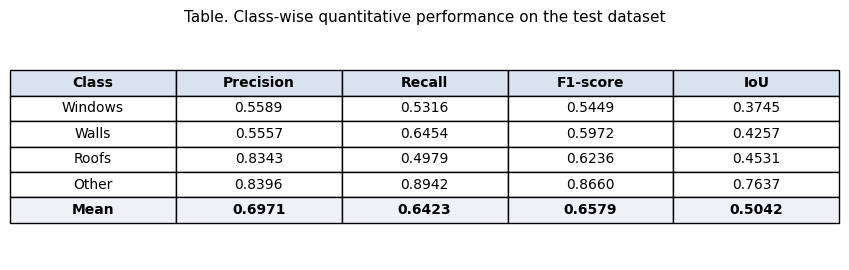

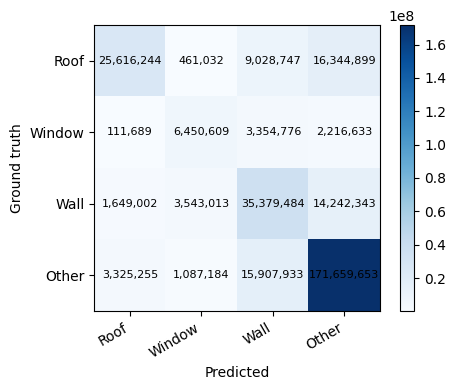

In [15]:
fig, ax = plt.subplots(figsize=(8.5, 2.8))
ax.axis('off')
ax.set_title(
    f'Table. Class-wise quantitative performance on the {eval_split} dataset',
    fontsize=11, pad=8,
)
cell_text = [metrics_df_fmt.iloc[i].tolist() for i in range(len(metrics_df_fmt))]
table = ax.table(
    cellText=cell_text,
    colLabels=list(metrics_df_fmt.columns),
    loc='center',
    cellLoc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.15, 1.45)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#d9e2ef')
        cell.set_text_props(weight='bold')
    elif r == len(cell_text):
        cell.set_facecolor('#eef2f7')
        cell.set_text_props(weight='bold')
plt.tight_layout()
fig.savefig(RESULTS_DIR / f'classwise_table_{eval_split}.png', dpi=160, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(4), CLASS_NAMES, rotation=30, ha='right')
ax.set_yticks(range(4), CLASS_NAMES)
ax.set_xlabel('Predicted')
ax.set_ylabel('Ground truth')
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
fig.savefig(RESULTS_DIR / f'confusion_matrix_{eval_split}.png', dpi=140, bbox_inches='tight')
plt.show()


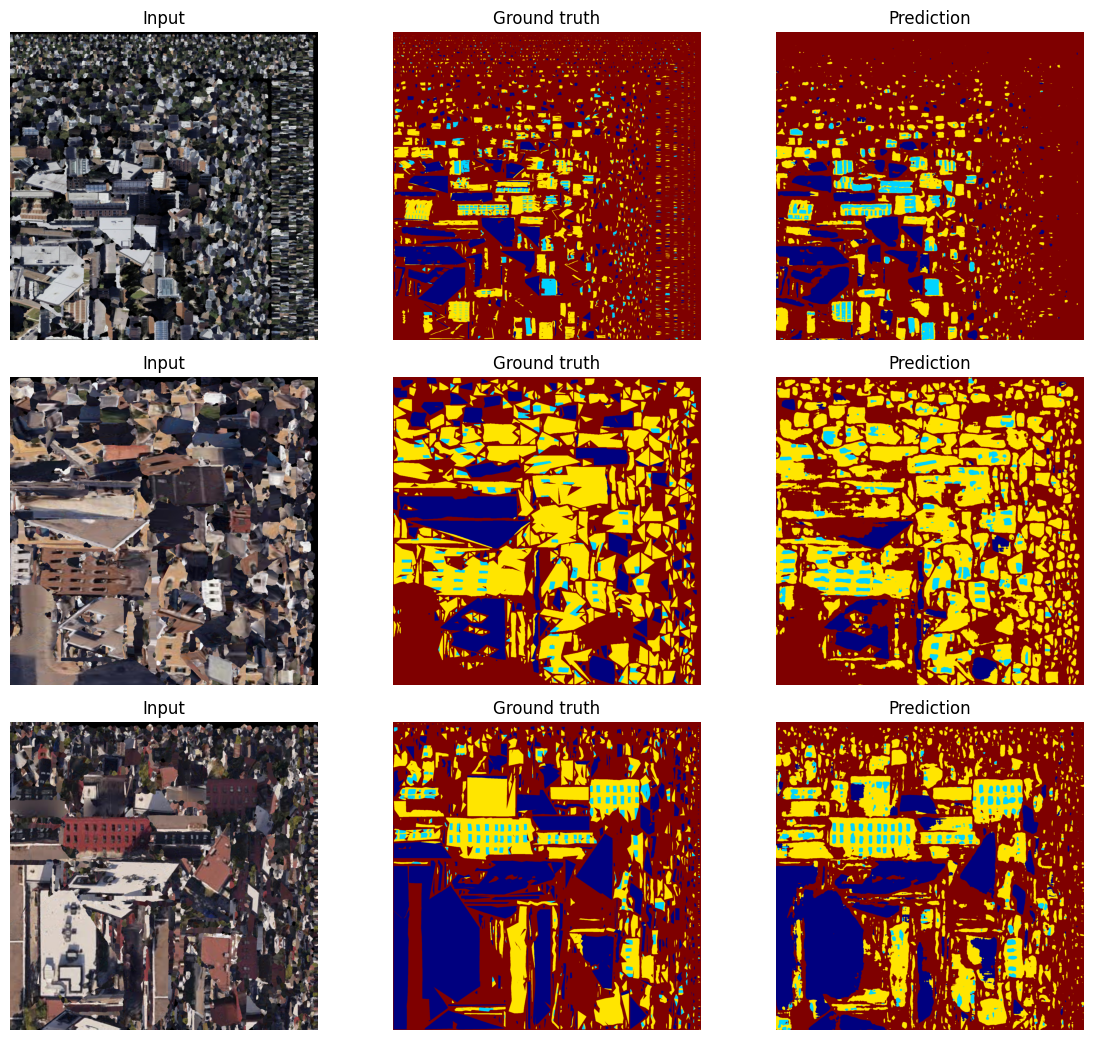

In [16]:
n_show = min(3, len(X_eval))
fig, axes = plt.subplots(n_show, 3, figsize=(12, 3.5 * n_show))
if n_show == 1:
    axes = np.expand_dims(axes, 0)
for i in range(n_show):
    axes[i, 0].imshow(np.clip(X_eval[i], 0, 1))
    axes[i, 0].set_title('Input')
    axes[i, 1].imshow(y_eval[i], cmap='jet', vmin=0, vmax=3)
    axes[i, 1].set_title('Ground truth')
    axes[i, 2].imshow(y_hat[i], cmap='jet', vmin=0, vmax=3)
    axes[i, 2].set_title('Prediction')
    for ax in axes[i]:
        ax.axis('off')
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'{eval_split}_samples.png', dpi=120, bbox_inches='tight')
plt.show()
